## what's the arthritis grade?

In [1]:
 !pip install -Uqq fastai

In [2]:
import warnings
import logging
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

In [3]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai

The basic steps we'll take are:

1. Use a curated Kaggle dataset of knee X-ray images
1. Prepare knee X-ray images across 5 arthritis severity grades (0-4)
1. Fine-tune a pretrained DenseNet169 neural network to predict the grade
1. Test the model on unseen X-rays and evaluate accuracy

## Step 1: Load knee X-ray images from dataset

We're using a pre-made knee X-ray dataset from Kaggle instead of searching the web. The dataset has images organized into folders 0-4 based on arthritis severity, where 0 is normal and 4 is severe arthritis.
Let's first explore the dataset structure to find the correct folder path

In [4]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/shashwatwork
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/0
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/3
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/1
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/4
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val/2
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val/0
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-datas

Now let's point to the training folder and see what's inside:

In [6]:
from fastai.vision.all import *
path = Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train')
path.ls()

[Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train/2'), Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train/0'), Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train/3'), Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train/1'), Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train/4')]

We'll use all 5 folders (0-4) representing arthritis severity grades, where 0 is normal and 4 is severe arthritis. Let's copy these into a clean working directory:

## Step 2: Train our model

In [21]:
from pathlib import Path
import shutil

for folder in ['0', '1', '2', '3', '4']:
    dest = Path('knee_data_graded')/folder
    dest.mkdir(exist_ok=True, parents=True)
    
    # Copy from both train and val
    for split in ['train']:
        src = Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity')/split/folder
        for f in src.ls():
            shutil.copy(f, dest/f.name)

Let's remove any corrupted images that might cause training to fail:

In [22]:
failed = verify_images(get_image_files(new_path))
failed.map(Path.unlink)
len(failed)

0

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

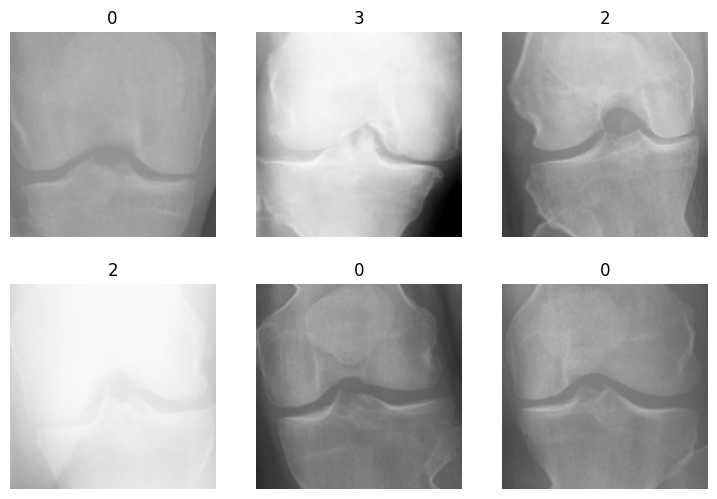

In [23]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')],
    batch_tfms=aug_transforms(do_flip=False, max_rotate=10, max_zoom=1.1, max_lighting=0.2)
).dataloaders(new_path, bs=32)

dls.show_batch(max_n=6)

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

inputs are images, outputs are categories (normal or arthritis)

    get_items=get_image_files, 

 finds all image files in the path

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

20% of data goes to validation set, 80% for training

    get_y=parent_label,

the folder name (normal/arthritis) is the label

    item_tfms=[Resize(192, method='squish')]

resize all images to 192x192.

Now let's fine-tune a pretrained densenet169 model on our dataset:

In [24]:
from fastai.callback.progress import ProgressCallback
learn = vision_learner(dls, densenet169, metrics=error_rate)
learn.remove_cb(ProgressCallback)
learn.fine_tune(5)

[0, 2.05914306640625, 1.7234965562820435, 0.6090909242630005, '00:48']
[0, 1.4444513320922852, 1.2125037908554077, 0.4780302941799164, '01:03']
[1, 1.1636838912963867, 1.0528284311294556, 0.4166666567325592, '01:02']
[2, 0.9798147678375244, 0.9085531234741211, 0.3840909004211426, '01:03']
[3, 0.8924920558929443, 0.8520893454551697, 0.35681816935539246, '01:03']
[4, 0.8099136352539062, 0.8683845400810242, 0.3545454442501068, '01:03']


Fine-tuning means starting with a model already trained on millions of images and adapting it to our specific task — predicting knee arthritis severity grade (0-4).

## Step 3: Evaluate our model

Let's test our model on a single image first:

In [25]:
test_img = get_image_files(Path('knee_data_graded/4'))[0]
grade, _, probs = learn.predict(PILImage.create(test_img))
print(f"Predicted grade: {grade}")
print(f"Probabilities: {probs}")
print(f"Classes: {dls.vocab}")

Predicted grade: 4
Probabilities: tensor([3.2965e-07, 1.5395e-07, 8.1956e-07, 5.4913e-04, 9.9945e-01])
Classes: ['0', '1', '2', '3', '4']


Now let's evaluate properly on the unseen test set — images the model has never seen during training:

In [26]:
base = Path('/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/test')
test_files = get_image_files(base/'0') + get_image_files(base/'1') + get_image_files(base/'2') + get_image_files(base/'3') + get_image_files(base/'4')
test_dl = dls.test_dl(test_files)
preds, _ = learn.get_preds(dl=test_dl)
pred_classes = preds.argmax(dim=1)

# Create actual labels matching dls.vocab order
vocab = dls.vocab
actual = []
for grade, folder in [('0', '0'), ('1', '1'), ('2', '2'), ('3', '3'), ('4', '4')]:
    idx = vocab.o2i[grade]
    actual += [idx] * len(get_image_files(base/folder))

correct = (pred_classes == tensor(actual)).float().mean()
print(f"Test accuracy: {correct:.4f}")

Test accuracy: 0.6419


This gives us a more honest accuracy than the validation score, since these images were completely unseen. As you can see, in just a few lines of code we built a medical image classifier that can predict knee arthritis severity grade (0-4) from X-rays with 64% accuracy — comparable to results from published research papers! Deep learning is making it easier than ever to build powerful AI applications. The key is understanding the fundamentals — data, training, and proper evaluation